In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_path = 'data/Diseases_and_Symptoms_dataset.csv'

df = pd.read_csv(data_path)

disease_col = "diseases"
symptom_cols = [c for c in df.columns if c != disease_col]

print("Dataset Shape:", df.shape)
print("Number of Diseases:", df[disease_col].nunique())
print("Number of Symptoms:", len(symptom_cols))

Dataset Shape: (96088, 231)
Number of Diseases: 100
Number of Symptoms: 230


In [3]:
le = LabelEncoder()
y = le.fit_transform(df[disease_col])

In [4]:
X = df[symptom_cols]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (76870, 230)
Test size: (19218, 230)


In [5]:
results = {}

#RandomForest
model_rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42
)

model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
results["RandomForest"] = acc_rf
print("\n=== Random Forest ===")
print("Accuracy:", acc_rf)
print(classification_report(y_test, pred_rf, target_names=le.classes_))


=== Random Forest ===
Accuracy: 0.8710583827661568
                                              precision    recall  f1-score   support

                           actinic keratosis       0.75      0.73      0.74       162
                         acute bronchiolitis       0.93      0.89      0.91       241
                            acute bronchitis       0.76      0.73      0.75       243
                          acute bronchospasm       0.54      0.63      0.58       162
                         acute kidney injury       0.98      0.99      0.98       162
                          acute pancreatitis       0.91      0.85      0.88       241
                             acute sinusitis       0.86      0.87      0.87       166
                                     allergy       0.94      0.98      0.96       161
                                      angina       0.93      0.97      0.95       165
                                     anxiety       0.95      0.97      0.96       240
 

In [6]:
#XGBoost
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.9,
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss'
)

model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, pred_xgb)
results["XGBoost"] = acc_xgb
print("\n=== XGBoost ===")
print("Accuracy:", acc_xgb)
print(classification_report(y_test, pred_xgb, target_names=le.classes_))


=== XGBoost ===
Accuracy: 0.8701737954001457
                                              precision    recall  f1-score   support

                           actinic keratosis       0.73      0.73      0.73       162
                         acute bronchiolitis       0.90      0.90      0.90       241
                            acute bronchitis       0.76      0.73      0.74       243
                          acute bronchospasm       0.58      0.60      0.59       162
                         acute kidney injury       0.97      0.98      0.98       162
                          acute pancreatitis       0.91      0.85      0.88       241
                             acute sinusitis       0.86      0.86      0.86       166
                                     allergy       0.95      0.98      0.97       161
                                      angina       0.92      0.97      0.95       165
                                     anxiety       0.95      0.96      0.95       240
       

In [7]:
model_lr = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial"
)

model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
results["Logistic Regression"] = acc_lr
print("\n=== Logistic Regression ===")
print("Accuracy:", acc_lr)
print(classification_report(y_test, pred_lr, target_names=le.classes_))

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic Regression ===
Accuracy: 0.8985326256634405
                                              precision    recall  f1-score   support

                           actinic keratosis       0.93      0.72      0.81       162
                         acute bronchiolitis       0.95      0.92      0.93       241
                            acute bronchitis       0.87      0.76      0.81       243
                          acute bronchospasm       0.66      0.78      0.71       162
                         acute kidney injury       0.98      0.99      0.98       162
                          acute pancreatitis       0.93      0.85      0.89       241
                             acute sinusitis       0.85      0.92      0.88       166
                                     allergy       0.94      0.98      0.96       161
                                      angina       0.95      0.98      0.96       165
                                     anxiety       0.97      0.97      0.97      

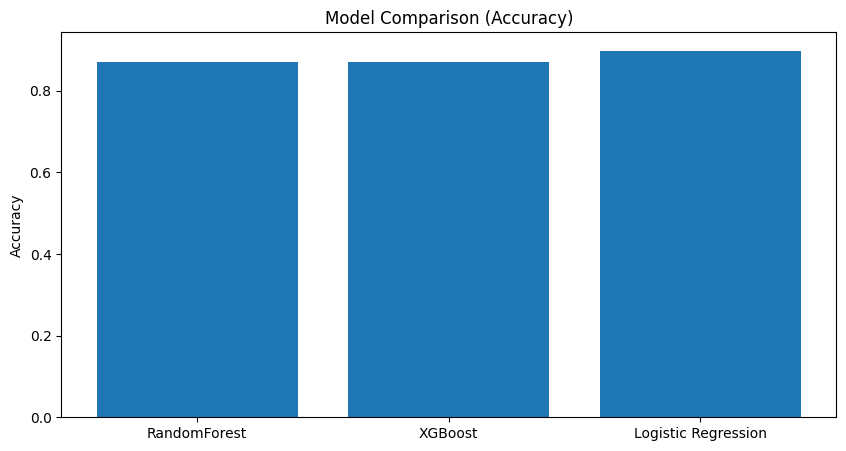


🔍 Best model: Logistic Regression


In [8]:
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()

print("\n🔍 Best model:", max(results, key=results.get))
